
*  DSC 530
*  Week 7 & 8 Assignment
*  Saebastion Cole

# Hands-on data analysis with Pandas

In [183]:
# Before I do anything I am starting with the imports.
# I am opting to stick with pandas with this assignment as pandas is the most widely used and probably the best to learn.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# I will also load the data from the csv here.
fb_stock = pd.read_csv("data/fb_stock_prices_2018.csv")
covid = pd.read_csv("data/covid19_cases.csv")
earthquakes = pd.read_csv("data/earthquakes.csv")

# Chapter 5 Exercises

## Exercise 1.

Plot the rolling 20-day minimum of the Facebook closing price using pandas.

Pandas has a built in rolling function that can calculate this.

In [184]:
# Using rolling to calculate

fb_stock["low_20"] = fb_stock["low"].rolling(20).min()
fb_stock["low_20"].head(20)

0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
5       NaN
6       NaN
7       NaN
8       NaN
9       NaN
10      NaN
11      NaN
12      NaN
13      NaN
14      NaN
15      NaN
16      NaN
17      NaN
18      NaN
19    175.8
Name: low_20, dtype: float64

## Exercise 2.

Create a histogram and KDE of the change from open to close in the price of Facebook stock.

In [185]:
# First calculate the difference between open and close
fb_stock["open_to_close"] = fb_stock["close"] - fb_stock["open"]
fb_stock["open_to_close"].head()

0    3.74
1    2.79
2   -0.57
3    1.26
4    1.08
Name: open_to_close, dtype: float64

<Axes: ylabel='Frequency'>

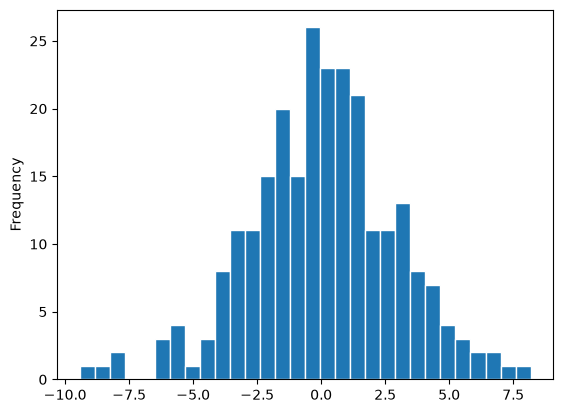

In [186]:
# Plot the histogram of the open to close difference
fb_stock["open_to_close"].plot(kind="hist", bins=30, edgecolor="white")

<Axes: ylabel='Density'>

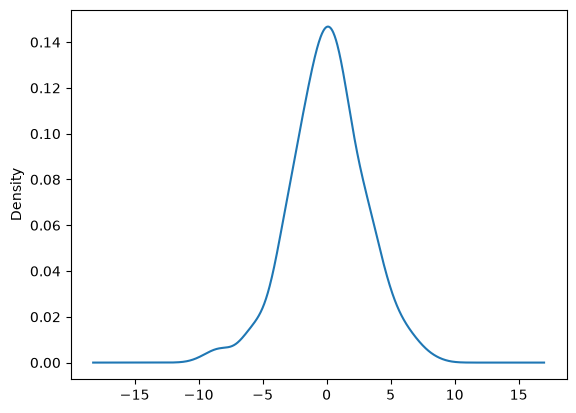

In [187]:
# Plot the KDE.
fb_stock["open_to_close"].plot(kind="kde")

## Exercise 3.

Using the earthquake data, create box plots for the magnitudes of each magType used in Indonesia.

<Axes: title={'center': 'mag'}, xlabel='magType'>

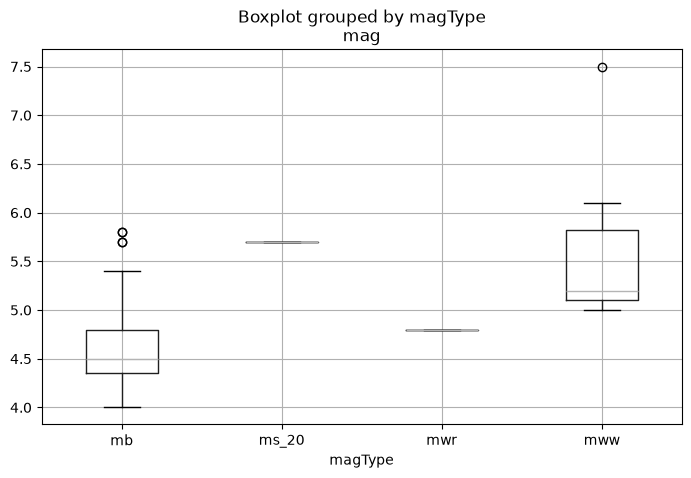

In [188]:
# Filter out the data
indonesia = earthquakes[earthquakes["parsed_place"] == "Indonesia"]

# Show the plot
indonesia.boxplot(column="mag", by="magType", figsize=(8, 5))

## Exercise 4.

Make a line plot of the difference between the weekly maximum high price and the weekly minimum low price for Facebook. This should be a single line.

<Axes: xlabel='date_obj'>

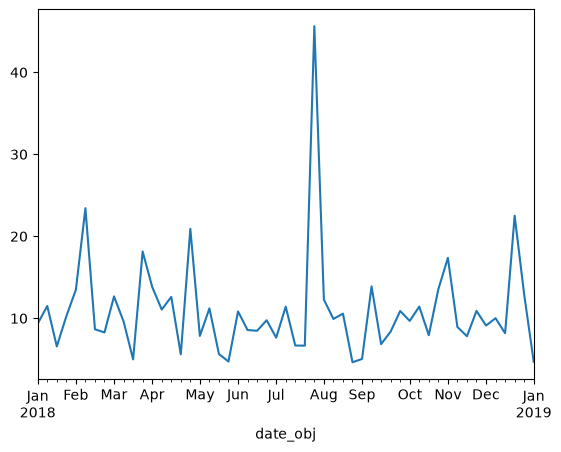

In [189]:
# Make a new column that has dates in an object format so we can use it for resampling
fb_stock["date_obj"] = pd.to_datetime(fb_stock["date"])

# Resampling with "w" week flag
fb_weekly = fb_stock.set_index("date_obj").resample("W").agg({"high": "max", "low": "min"})
fb_weekly["diff"] = fb_weekly["high"] - fb_weekly["low"]

# Show the plot
fb_weekly["diff"].plot(kind="line")

# Chapter 6 Exercises

## Exercise 1.

Using Seaborn, create a heatmap to visualize the correlation coefficients between earthquake magnitude and whether there was a tsunami for earthquakes measured with the mb magnitude type.


<Axes: >

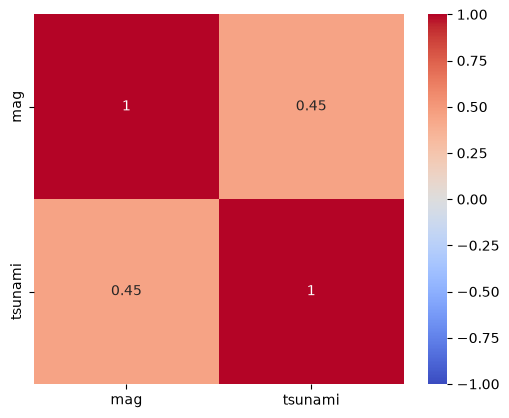

In [190]:
mb_earthquakes = earthquakes[earthquakes["magType"] == "mb"]

# corr() on just these two columns gives me a 2x2 correlation matrix to feed the heatmap.
mb_corr = mb_earthquakes[["mag", "tsunami"]].corr()

# center=0 with a diverging colormap keeps the sign of the correlation readable,
# and vmin/vmax pin the scale to the full -1 to 1 range so the color isn't misleading.
sns.heatmap(
    mb_corr,
    annot=True,
    center=0,
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
    square=True
)

## Exercise 2.

Create a box plot of Facebook volume traded and closing prices and draw reference lines for the bounds of a Tukey fence with a multiplier of 1.5. The bounds will be at Q1 − 1.5 × IQR and Q3 + 1.5 × IQR. Be sure to use the quantile() method on the data to make this easier. Pick whichever orientation you prefer for the plot, but make sure to use subplots.

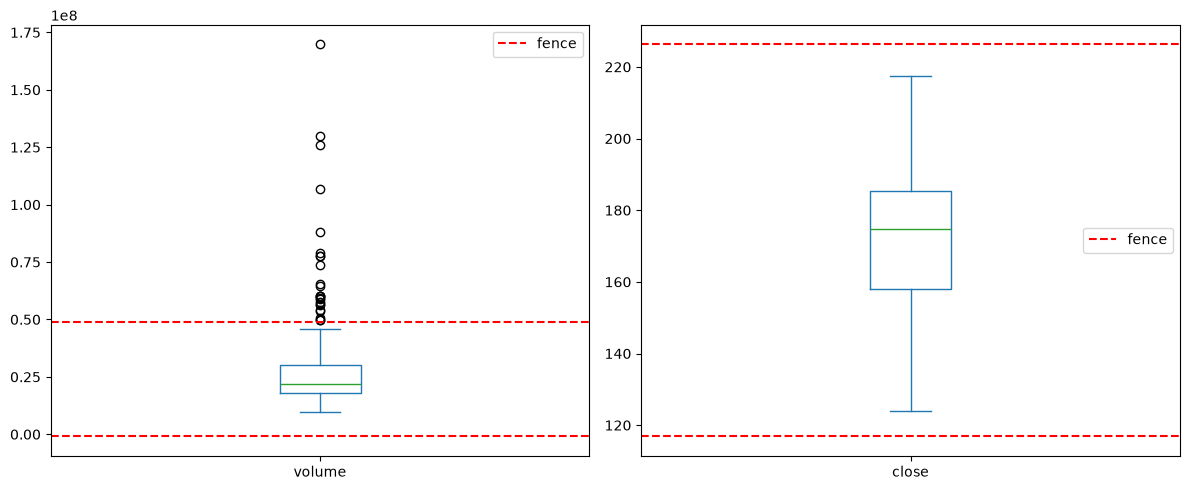

In [191]:
# Create the side by size boxplots
axes = fb_stock[["volume", "close"]].plot(
    kind="box", subplots=True, layout=(1, 2), figsize=(12, 5)
)

# Resize the axes to make the data more meaningful otherwise they will be incredibly zoomed out for close since volume is much higher
for ax, column in zip(axes, ["volume", "close"]):
    # Calculate the IQR
    q1 = fb_stock[column].quantile(0.25)
    q3 = fb_stock[column].quantile(0.75)
    iqr = q3 - q1

    # Draw the line for IQR
    ax.axhline(q1 - 1.5 * iqr, color="red", linestyle="--", label="fence")
    ax.axhline(q3 + 1.5 * iqr, color="red", linestyle="--")
    ax.legend()

plt.tight_layout()
plt.show()